# Airline Passenger Satisfaction - ML Project

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import joblib
from pathlib import Path

from sklearn.base import clone
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

## 2. Introduction

**About the data:** Airline Passenger Satisfaction survey containing flight details and passenger ratings for different airline services.

**Project goal:** Predict whether a passenger is *satisfied* or *neutral/dissatisfied* with their flight experience.

**Target column:** `satisfaction`

In [2]:
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
df = pd.read_csv(path + "/train.csv")
df = df.drop(columns=["Unnamed: 0", "id"])
df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


Data preview looks clean after removing ID columns, so the next step is checking column types and missing values.

## 3. Exploratory Data Analysis

### 3.1 Shape, Info, Describe

In [3]:
print("Shape:", df.shape)
df.info()
# Quick look at size, columns and data types.

Shape: (103904, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103904 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Gender                             103904 non-null  object 
 1   Customer Type                      103904 non-null  object 
 2   Age                                103904 non-null  int64  
 3   Type of Travel                     103904 non-null  object 
 4   Class                              103904 non-null  object 
 5   Flight Distance                    103904 non-null  int64  
 6   Inflight wifi service              103904 non-null  int64  
 7   Departure/Arrival time convenient  103904 non-null  int64  
 8   Ease of Online booking             103904 non-null  int64  
 9   Gate location                      103904 non-null  int64  
 10  Food and drink                     103904 non-null  int64  
 11  Online boarding    

The dataset mixes numeric and categorical fields with good size, so we run quick stats and null checks before preprocessing.

In [4]:
df.describe()
# Statistics for numeric columns to spot ranges and possible outliers.

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Delay-related stats suggest skew and extremes, so we confirm this with boxplots and then handle outliers.

### 3.2 Target Balance

satisfaction
neutral or dissatisfied    0.566667
satisfied                  0.433333
Name: proportion, dtype: float64


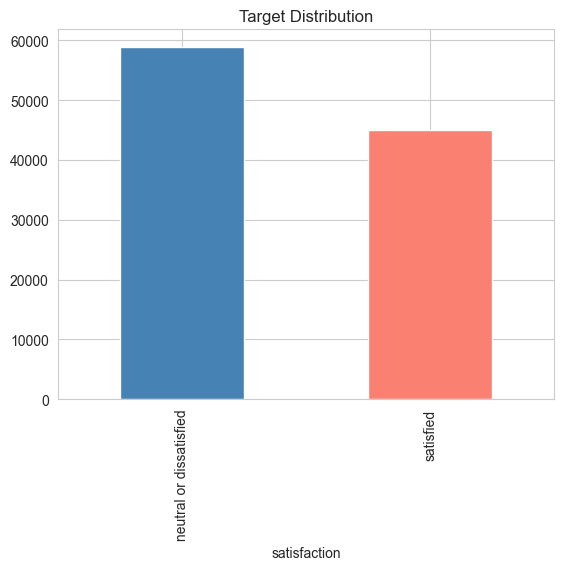

In [5]:
print(df['satisfaction'].value_counts(normalize=True))
df['satisfaction'].value_counts().plot.bar(color=['steelblue','salmon'])
plt.title('Target Distribution')
plt.show()
# Classes are reasonably balanced, no need for resampling.

Target classes are fairly balanced, so we keep a stratified split and skip resampling.

### 3.3 Plots

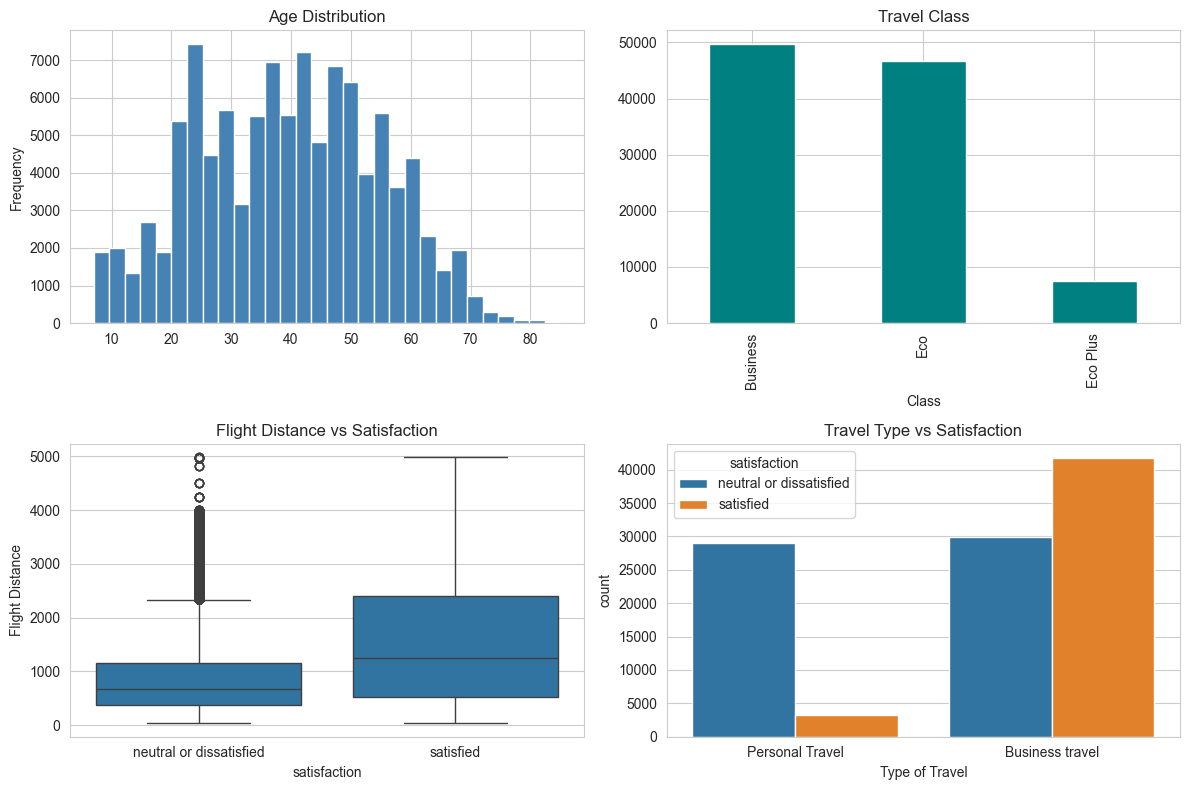

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Age'].plot.hist(bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Age Distribution')

df['Class'].value_counts().plot.bar(ax=axes[0,1], color='teal')
axes[0,1].set_title('Travel Class')

sns.boxplot(x='satisfaction', y='Flight Distance', data=df, ax=axes[1,0])
axes[1,0].set_title('Flight Distance vs Satisfaction')

sns.countplot(x='Type of Travel', hue='satisfaction', data=df, ax=axes[1,1])
axes[1,1].set_title('Travel Type vs Satisfaction')

plt.tight_layout()
plt.show()
# Business travelers and longer flights tend to show higher satisfaction.

Satisfaction changes clearly with class, travel type, and distance, so these stay as key modeling features.

### 3.4 Relationships Between Variables

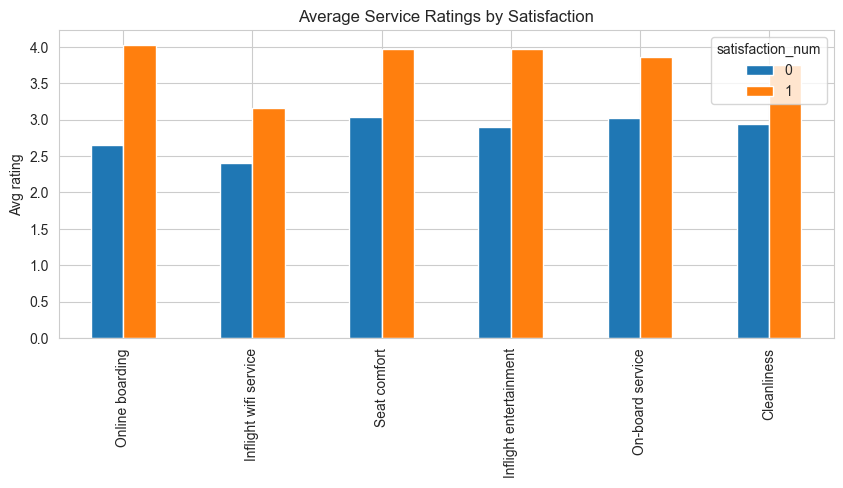

In [7]:
service_cols = ['Online boarding', 'Inflight wifi service', 'Seat comfort',
                'Inflight entertainment', 'On-board service', 'Cleanliness']
tmp = df.copy()
tmp['satisfaction_num'] = (tmp['satisfaction'] == 'satisfied').astype(int)
tmp[service_cols + ['satisfaction_num']].groupby('satisfaction_num').mean().T.plot.bar(figsize=(10,4))
plt.title('Average Service Ratings by Satisfaction')
plt.ylabel('Avg rating')
plt.show()
# Satisfied passengers consistently rate services higher, especially online boarding and entertainment.

Service ratings, especially online boarding and entertainment, separate the classes well, so we keep them as strong predictors.

## 4. Preprocessing

### 4.1 Handling Missing Values

In [8]:
print(df.isnull().sum()[df.isnull().sum() > 0])
# Only 'Arrival Delay in Minutes' has nulls.

Arrival Delay in Minutes    310
dtype: int64


Missing values are concentrated in one delay column, so we apply targeted imputation instead of broad cleanup.

In [ ]:
delay_col = 'Arrival Delay in Minutes'

mean_val = df[delay_col].mean()
median_val = df[delay_col].median()
mode_val = df[delay_col].mode()[0]

print('Mean:', round(mean_val, 2))
print('Median:', round(median_val, 2))
print('Most frequent:', round(mode_val, 2))

# Decision: use median because delays are right-skewed and median is more stable.
df[delay_col] = df[delay_col].fillna(median_val)
print('Remaining nulls:', df.isnull().sum().sum())

Remaining nulls: 0


Median is the safer fill for this skewed delay feature, then we move to outlier handling.

### 4.2 Encoding Categorical Features

In [10]:
df_enc = df.copy()
le = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])
# Label encoding is enough since most categorical features have only 2-3 levels.

### 4.3 Outlier Check

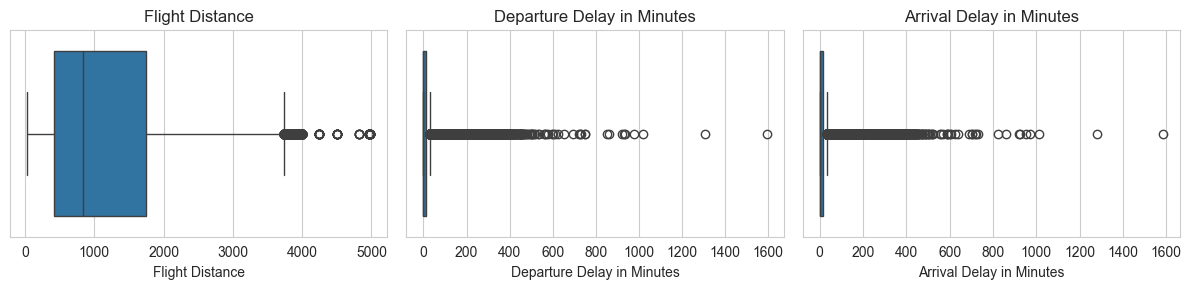

In [ ]:
outlier_cols = ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, col in zip(axes, outlier_cols):
    sns.boxplot(x=df_enc[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

outlier_summary = {}
for col in outlier_cols:
    q1 = df_enc[col].quantile(0.25)
    q3 = df_enc[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df_enc[col] < lower) | (df_enc[col] > upper)
    outlier_summary[col] = int(mask.sum())

print('Detected outliers (IQR rule):')
print(pd.Series(outlier_summary))

# Decision: IQR capping for all outlier columns to keep all rows and reduce extreme-value impact on SVM.
for col in outlier_cols:
    q1 = df_enc[col].quantile(0.25)
    q3 = df_enc[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_enc[col] = df_enc[col].clip(lower=lower, upper=upper)

print('Outlier handling method used: IQR capping')

Outliers are mainly in distance and delay features, so we use IQR capping to reduce their impact without dropping rows.

### 4.4 Correlation & Feature Selection

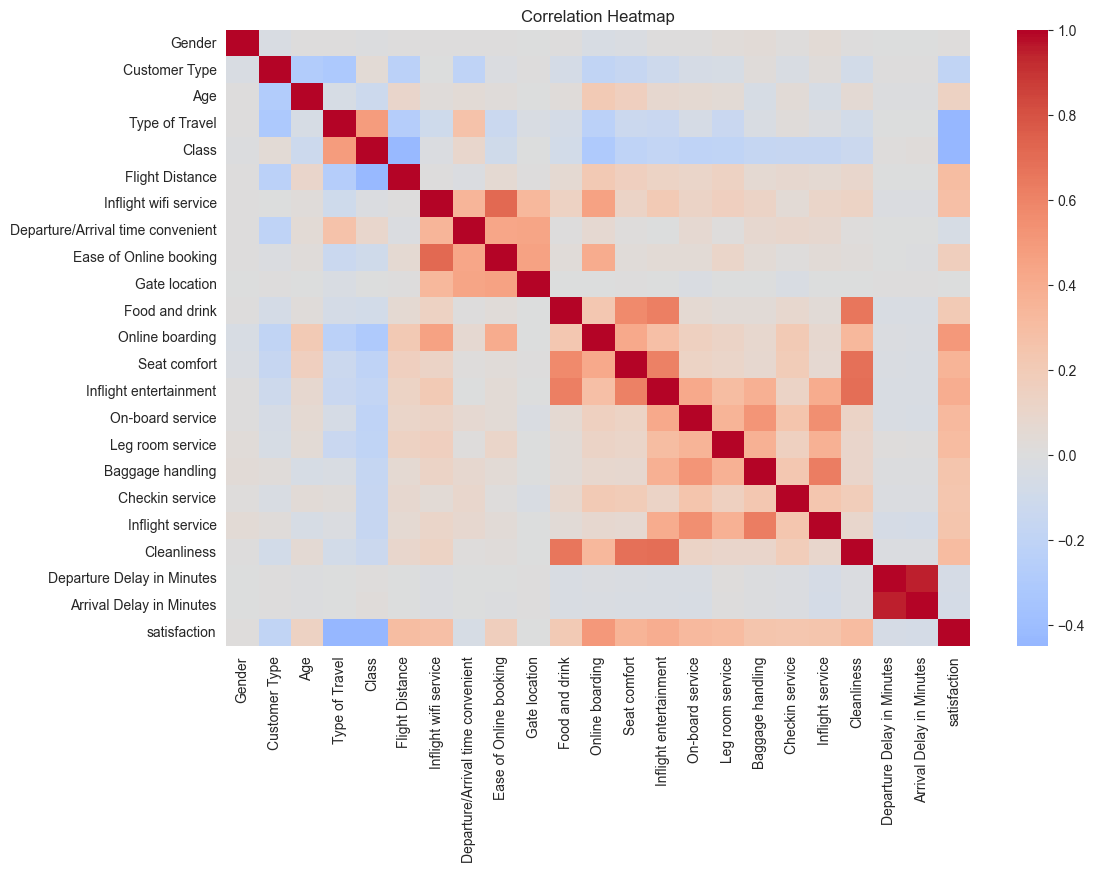

In [12]:
plt.figure(figsize=(12, 8))
corr = df_enc.corr()
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

Correlation shows overlapping feature groups, so we keep the features most related to the target and remove weak ones.

In [13]:
target_corr = corr['satisfaction'].drop('satisfaction').abs().sort_values(ascending=False)
print(target_corr)
# Show how strongly each feature correlates with the target.

Online boarding                      0.503557
Class                                0.449321
Type of Travel                       0.449000
Inflight entertainment               0.398059
Seat comfort                         0.349459
On-board service                     0.322383
Leg room service                     0.313131
Cleanliness                          0.305198
Flight Distance                      0.298780
Inflight wifi service                0.284245
Baggage handling                     0.247749
Inflight service                     0.244741
Checkin service                      0.236174
Food and drink                       0.209936
Customer Type                        0.187638
Ease of Online booking               0.171705
Age                                  0.137167
Arrival Delay in Minutes             0.067232
Departure Delay in Minutes           0.058261
Departure/Arrival time convenient    0.051601
Gender                               0.012211
Gate location                     

A small subset carries most target signal, so we apply a threshold and drop low-value features.

In [ ]:
# Keep features with useful signal and remove very weak ones (< 0.05).
weak_features = target_corr[target_corr < 0.05].index.tolist()
selected_features = target_corr[target_corr >= 0.05].index.tolist()

print('Dropping weak features:', weak_features)
print('Selected features count:', len(selected_features))

df_final = df_enc[selected_features + ['satisfaction']].copy()
print('Final shape:', df_final.shape)

Dropping: ['Gender', 'Gate location']
Final shape: (103904, 21)


After filtering weak features the data is cleaner, so we train baseline models on this reduced set.

## 5. Modeling

### 5.1 Train/Test Split + Scaling

In [15]:
X = df_final.drop('satisfaction', axis=1)
y = df_final['satisfaction']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
# SVM needs scaling. Tree-based models do not, but using the same scaled data keeps the pipeline simple.

### 5.2 Baseline Models

Train a quick baseline version of each model to get a reference performance.

In [ ]:
# Use a sample for SVM baseline because full data takes longer.
sample_size = min(10000, len(X_train_s))
sample_idx = np.random.RandomState(42).choice(len(X_train_s), size=sample_size, replace=False)

svm_base = SVC(probability=True, random_state=42).fit(X_train_s[sample_idx], y_train.iloc[sample_idx])
dt_base = DecisionTreeClassifier(random_state=42).fit(X_train_s, y_train)
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train_s, y_train)
print('Baseline models trained.')

Baseline models trained.


Baseline models are ready, so now we measure how much tuning actually improves performance.

### 5.3 Tuned Models

Use small `GridSearchCV` to fine-tune the most important hyperparameters.

In [17]:
# SVM tuning on a sample to keep time reasonable
svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42),
    {'C': [1, 5], 'kernel': ['rbf']},
    cv=3, n_jobs=-1
)
svm_grid.fit(X_train_s[sample_idx], y_train.iloc[sample_idx])
svm_tuned = svm_grid.best_estimator_
print("SVM best params:", svm_grid.best_params_)

SVM best params: {'C': 5, 'kernel': 'rbf'}


SVM depends strongly on scaling and outlier control, so we compare it directly with tuned tree models.

In [18]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {'max_depth': [8, 12, 16], 'min_samples_leaf': [1, 4]},
    cv=3, n_jobs=-1
)
dt_grid.fit(X_train_s, y_train)
dt_tuned = dt_grid.best_estimator_
print("Decision Tree best params:", dt_grid.best_params_)

Decision Tree best params: {'max_depth': 16, 'min_samples_leaf': 1}


Depth and leaf tuning should reduce overfitting, so we validate gains on test metrics only.

In [19]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {'n_estimators': [100, 200], 'max_depth': [None, 16]},
    cv=3, n_jobs=-1
)
rf_grid.fit(X_train_s, y_train)
rf_tuned = rf_grid.best_estimator_
print("Random Forest best params:", rf_grid.best_params_)

Random Forest best params: {'max_depth': None, 'n_estimators': 200}


Random Forest is ready for final selection, and we choose by test performance rather than model complexity.

## 6. Evaluation

In [20]:
def evaluate(name, model, X_eval, y_eval):
    pred = model.predict(X_eval)
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_eval, pred),
        'Precision': precision_score(y_eval, pred),
        'Recall':    recall_score(y_eval, pred),
        'F1':        f1_score(y_eval, pred)
    }

models = {
    'SVM (baseline)':        svm_base,
    'SVM (tuned)':           svm_tuned,
    'Decision Tree (base)':  dt_base,
    'Decision Tree (tuned)': dt_tuned,
    'Random Forest (base)':  rf_base,
    'Random Forest (tuned)': rf_tuned,
}

results = pd.DataFrame([evaluate(n, m, X_test_s, y_test) for n, m in models.items()])
results = results.sort_values('F1', ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest (tuned),0.962995,0.969021,0.944808,0.956761
1,Random Forest (base),0.962418,0.968124,0.944364,0.956096
2,Decision Tree (tuned),0.953804,0.953444,0.939256,0.946297
3,SVM (tuned),0.947211,0.947386,0.929817,0.938519
4,Decision Tree (base),0.944084,0.929283,0.942699,0.935943
5,SVM (baseline),0.942207,0.944419,0.920822,0.932471


The comparison table gives the real performance gap, so we pick the model with the best balanced F1 on test data.

### 6.1 Confusion Matrices

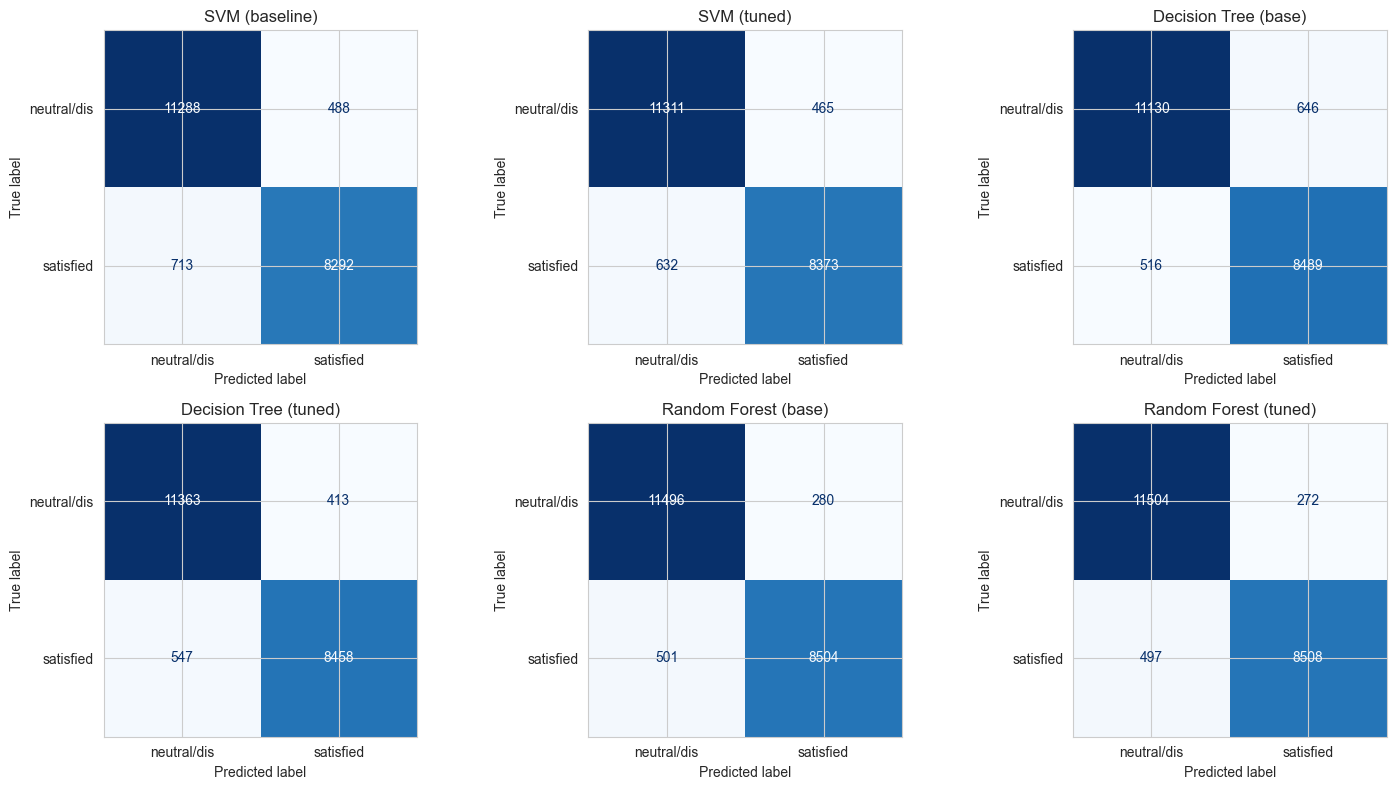

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, model) in zip(axes.flatten(), models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    ConfusionMatrixDisplay(cm, display_labels=['neutral/dis', 'satisfied']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

Confusion matrices show error types clearly, so we prefer the model with fewer costly misclassifications.

### 6.2 Best Model

In [22]:
best_name = results.loc[0, 'Model']
best_model = models[best_name]
print(f"Best model: {best_name}")
print(results.loc[0])

Best model: Random Forest (tuned)
Model        Random Forest (tuned)
Accuracy                  0.962995
Precision                 0.969021
Recall                    0.944808
F1                        0.956761
Name: 0, dtype: object


The best model is fixed from evaluation, so we freeze this same pipeline for deployment.

## 7. Deployment Preparation

Save the best model with only top selected features so it can be loaded directly in a real app file (`app.py`).

In [ ]:
# Use feature selection result to keep the app simple.
app_top_features = target_corr.head(5).index.tolist()
print('Top features for deployment:')
print(app_top_features)

Top features used by the app:
Online boarding           0.171011
Inflight wifi service     0.151098
Class                     0.100905
Type of Travel            0.099468
Inflight entertainment    0.055704
dtype: float64


Top deployment features keep most signal with simpler inputs, so we retrain and save the final artifact on them.

In [ ]:
# Retrain the best model on top features only, then save it.
X_train_top = X_train[app_top_features].copy()
X_test_top = X_test[app_top_features].copy()

scaler_top = StandardScaler()
X_train_top_s = scaler_top.fit_transform(X_train_top)
X_test_top_s = scaler_top.transform(X_test_top)

deploy_model = clone(best_model)
deploy_model.fit(X_train_top_s, y_train)

deploy_pred = deploy_model.predict(X_test_top_s)
deploy_f1 = f1_score(y_test, deploy_pred)
print('Deployment model (top features) F1:', round(deploy_f1, 4))

feature_defaults = X_train_top.median().to_dict()
feature_bounds = {
    c: {'min': float(X_train_top[c].min()), 'max': float(X_train_top[c].max())}
    for c in app_top_features
}

artifact = {
    'model_name': best_name,
    'model': deploy_model,
    'scaler': scaler_top,
    'feature_names': app_top_features,
    'feature_defaults': feature_defaults,
    'feature_bounds': feature_bounds,
    'label_map': {0: 'Neutral or Dissatisfied', 1: 'Satisfied'}
}

project_dir = Path('project') if Path('project').exists() else Path('.')
model_path = project_dir / 'best_model.joblib'
joblib.dump(artifact, model_path)
print(f'Saved: {model_path.resolve()}')

Example input: {'Online boarding': 3.0, 'Inflight wifi service': 3.0, 'Class': 1.0, 'Type of Travel': 0.0, 'Inflight entertainment': 4.0}
Prediction: Neutral / Dissatisfied
Probability satisfied: 20.50%
Probability not satisfied: 79.50%


The saved artifact includes model, scaler, and metadata together, so app predictions stay consistent with notebook results.